# Student Academic Success Prediction System

## 1. Problem Understanding

### 1.1 Problem Statement

Academic performance is an important indicator of a student's educational progress. In Pakistan, student academic outcomes can be influenced by previous academic performance, attendance, study habits, parental education, parental income, school type, extra tuition, previous failures, and other educational factors.

Educational institutions may face difficulty in identifying students who are at risk of poor academic performance at an early stage.

This project aims to develop a Machine Learning-based Student Academic Success Prediction System that uses students' academic, demographic, socioeconomic, and behavioral information to predict their HSSC-II academic grade.

The project uses the BISEP Student Performance Prediction Dataset, which contains student-related information from Pakistan.

### 1.2 Why This Problem is Important for Pakistan

Education plays an important role in the social and economic development of Pakistan. Early identification of students who may experience academic difficulties can help educational institutions provide timely academic support.

A data-driven prediction system can help identify patterns associated with academic performance and support teachers and institutions in making informed decisions.

Potential applications include:

- Identifying students who may require additional academic support.
- Understanding factors associated with academic outcomes.
- Supporting early academic intervention.
- Improving student monitoring and educational planning.

### 1.3 Project Objectives

The main objectives of this project are:

1. To analyze student academic, demographic, socioeconomic, and behavioral information.
2. To perform Exploratory Data Analysis (EDA) and identify important patterns.
3. To identify data quality issues such as missing values, duplicates, inconsistencies, and outliers.
4. To preprocess the dataset for Machine Learning.
5. To identify relevant features using multiple feature selection techniques.
6. To create meaningful features that may improve prediction.
7. To handle class imbalance where required.
8. To develop and compare multiple Machine Learning classification models.
9. To evaluate the models using appropriate classification metrics.
10. To select the best-performing model for predicting HSSC-II academic grades.

### 1.4 Expected Outcomes

The project is expected to:

- Provide insights into student academic performance.
- Identify important features associated with academic outcomes.
- Produce a clean and Machine Learning-ready dataset.
- Develop multiple classification models.
- Compare model performance using appropriate evaluation metrics.
- Identify the best-performing model based on the evaluation results.

### 1.5 Problem Type

This project is a Supervised Machine Learning Classification problem.

The target variable is `HSSC_II_Grade`, which contains six academic grade classes:

- A-ONE
- A
- B
- C
- D
- Fail

The models learn from historical student information and predict the academic grade class of a student.

## 2. Data Collection

### 2.1 Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
df = pd.read_csv("student_performance.csv")
df.head()

,Student_ID,Region,Gender,Enrollment_Type,Subject_Group,SSC_I_Marks,SSC_II_Marks,HSSC_I_Marks,Attendance_Rate,Parent_Education_Level,Parent_Income,Study_Hours,Extra_Tuition,School_Type,Previous_Failures,Co_Curricular_Activities,Exam_Attempts,HSSC_II_Marks,HSSC_II_Grade
0,1,Mohmand,Male,Regular,Science,682,772,390,59.84,College,Medium,3.27,No,Private,1,No,2,814,A-ONE
1,2,Mohmand,Male,Regular,Science,535,532,800,76.71,Graduate,Low,2.32,Yes,Public,2,Yes,1,504,C
2,3,Mohmand,Female,Private,Arts,697,692,331,81.94,College,Low,4.64,Yes,Private,1,No,2,572,C
3,4,Khyber,Female,Regular,Arts,705,584,603,96.10,College,Medium,3.83,No,Public,0,Yes,2,543,C
4,5,Chitral,Female,Regular,Arts,308,737,812,95.75,High School,Medium,4.47,No,Public,2,No,1,608,B


### 2.2 Dataset Source and Description

**Dataset Name:** BISEP – Student Performance Prediction Dataset

**Source:** Kaggle

**Dataset Size:** 90,000 records × 19 columns

The dataset contains academic, demographic, socioeconomic, and behavioral information of students from Pakistan.

The target variable is `HSSC_II_Grade`, which represents the student's final academic grade.

The dataset contains information related to:

- Previous academic marks
- Attendance
- Study hours
- Parental education
- Parental income
- Extra tuition
- School type
- Previous failures
- Examination attempts
- Student demographic information

### 2.3 Dataset Shape

In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 90000
Number of columns: 19


### 2.4 Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Student_ID                90000 non-null  int64  
 1   Region                    90000 non-null  object 
 2   Gender                    90000 non-null  object 
 3   Enrollment_Type           90000 non-null  object 
 4   Subject_Group             90000 non-null  object 
 5   SSC_I_Marks               90000 non-null  int64  
 6   SSC_II_Marks              90000 non-null  int64  
 7   HSSC_I_Marks              90000 non-null  int64  
 8   Attendance_Rate           90000 non-null  float64
 9   Parent_Education_Level    90000 non-null  object 
 10  Parent_Income             90000 non-null  object 
 11  Study_Hours               90000 non-null  float64
 12  Extra_Tuition             90000 non-null  object 
 13  School_Type               90000 non-null  object 
 14  Previo

### 2.5 Statistical Summary

In [4]:
df.describe()

,Student_ID,SSC_I_Marks,SSC_II_Marks,HSSC_I_Marks,Attendance_Rate,Study_Hours,Previous_Failures,Exam_Attempts,HSSC_II_Marks
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,45000.500000,574.299322,574.143433,574.798967,74.900257,2.995347,0.998489,1.501056,574.722522
std,25980.906451,158.605687,159.095756,158.364616,14.398339,1.155207,0.816813,0.500002,158.775415
min,1.000000,300.000000,300.000000,300.000000,50.000000,1.000000,0.000000,1.000000,300.000000
25%,22500.750000,437.000000,436.000000,437.000000,62.450000,2.000000,0.000000,1.000000,437.000000
50%,45000.500000,575.000000,574.000000,576.000000,74.830000,2.990000,1.000000,2.000000,576.000000
75%,67500.250000,711.000000,712.000000,712.000000,87.360000,4.000000,2.000000,2.000000,712.000000
max,90000.000000,849.000000,849.000000,849.000000,100.000000,5.000000,2.000000,2.000000,849.000000


### 2.6 Column Names

In [5]:
print("Dataset Columns:")
for column in df.columns:
    print("-", column)

Dataset Columns:
- Student_ID
- Region
- Gender
- Enrollment_Type
- Subject_Group
- SSC_I_Marks
- SSC_II_Marks
- HSSC_I_Marks
- Attendance_Rate
- Parent_Education_Level
- Parent_Income
- Study_Hours
- Extra_Tuition
- School_Type
- Previous_Failures
- Co_Curricular_Activities
- Exam_Attempts
- HSSC_II_Marks
- HSSC_II_Grade


### 2.7 Check Data Types

In [6]:
df.dtypes

Student_ID                    int64
Region                       object
Gender                       object
Enrollment_Type              object
Subject_Group                object
SSC_I_Marks                   int64
SSC_II_Marks                  int64
HSSC_I_Marks                  int64
Attendance_Rate             float64
Parent_Education_Level       object
Parent_Income                object
Study_Hours                 float64
Extra_Tuition                object
School_Type                  object
Previous_Failures             int64
Co_Curricular_Activities     object
Exam_Attempts                 int64
HSSC_II_Marks                 int64
HSSC_II_Grade                object
dtype: object

In [7]:
print("Numerical columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include="object").columns.tolist())

Numerical columns:
['Student_ID', 'SSC_I_Marks', 'SSC_II_Marks', 'HSSC_I_Marks', 'Attendance_Rate', 'Study_Hours', 'Previous_Failures', 'Exam_Attempts', 'HSSC_II_Marks']

Categorical columns:
['Region', 'Gender', 'Enrollment_Type', 'Subject_Group', 'Parent_Education_Level', 'Parent_Income', 'Extra_Tuition', 'School_Type', 'Co_Curricular_Activities', 'HSSC_II_Grade']


##  3. Data Understanding – Phase 1 (Insights & Pattern Understanding)

### 3.1 SSC-I Marks Distribution

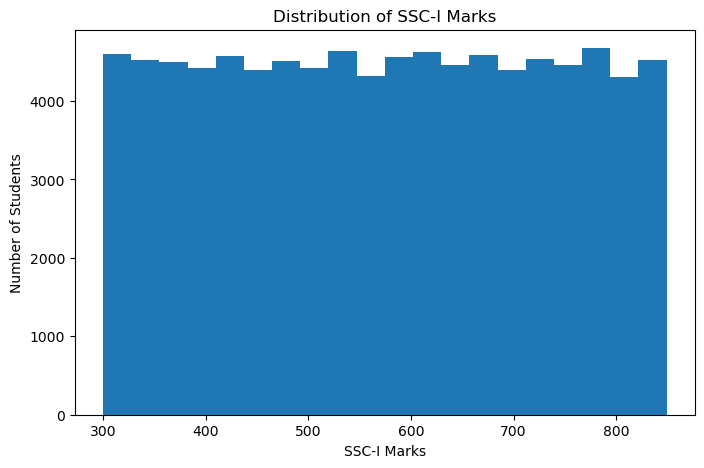

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["SSC_I_Marks"], bins=20)

plt.title("Distribution of SSC-I Marks")
plt.xlabel("SSC-I Marks")
plt.ylabel("Number of Students")

plt.show()

#### Observation

The SSC-I marks show a broad distribution across the students. The values are spread across the available marks range rather than being concentrated at a single value. This indicates variation in students' previous academic performance.

## 3.2 HSSC-I Marks Distribution

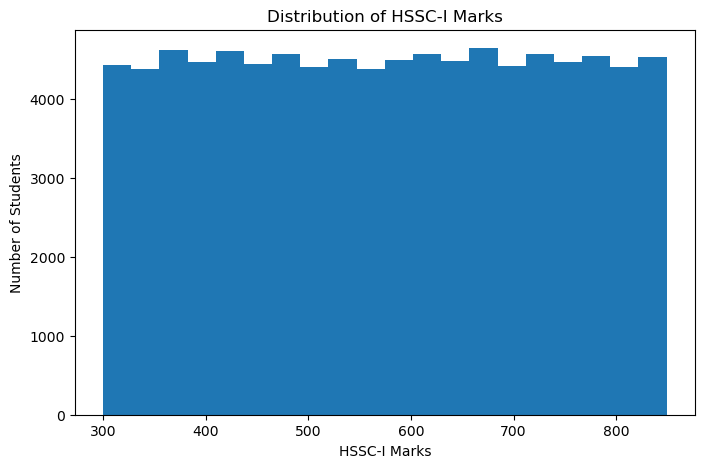

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["HSSC_I_Marks"], bins=20)

plt.title("Distribution of HSSC-I Marks")
plt.xlabel("HSSC-I Marks")
plt.ylabel("Number of Students")

plt.show()

#### Observation

HSSC-I marks show noticeable variation among students. The distribution provides an initial view of differences in students' academic performance before the final HSSC-II outcome.

## 3.3 Attendance Rate Distribution

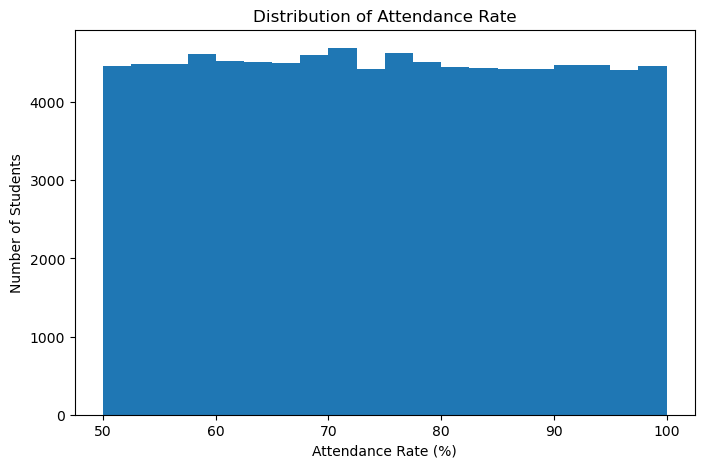

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["Attendance_Rate"], bins=20)

plt.title("Distribution of Attendance Rate")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Number of Students")

plt.show()

#### Observation

Attendance rates are distributed across a relatively wide range. This variation makes attendance a potentially useful variable for investigating differences in academic outcomes.

## 3.4 Students by Gender

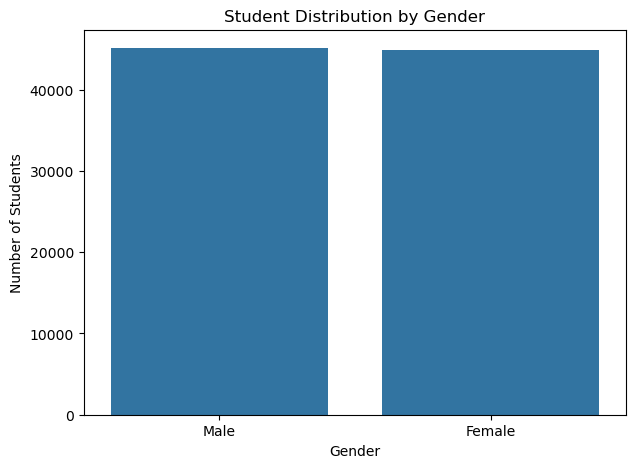

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Gender")

plt.title("Student Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.show()

#### Observation

The bar chart shows the number of male and female students in the dataset. The distribution can be used to understand the demographic composition of the student sample.

## 3.5 HSSC-II Grade Distribution

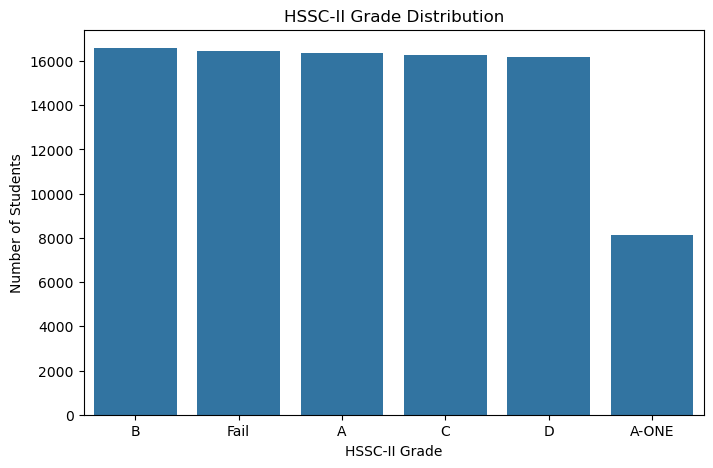

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="HSSC_II_Grade",
    order=df["HSSC_II_Grade"].value_counts().index
)

plt.title("HSSC-II Grade Distribution")
plt.xlabel("HSSC-II Grade")
plt.ylabel("Number of Students")

plt.show()

#### Observation

The target variable contains six academic grade classes. Most classes have relatively similar frequencies, while A-ONE has a smaller representation than the other major classes.

## 3.6 Gender Distribution

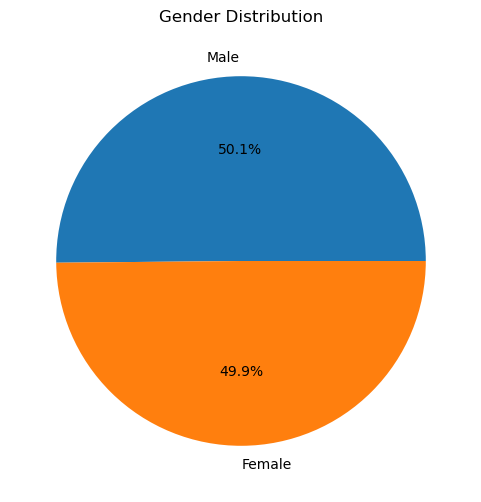

In [13]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()

#### Observation

The pie chart shows the percentage distribution of students by gender.

## 3.7 HSSC-II Marks Boxplot

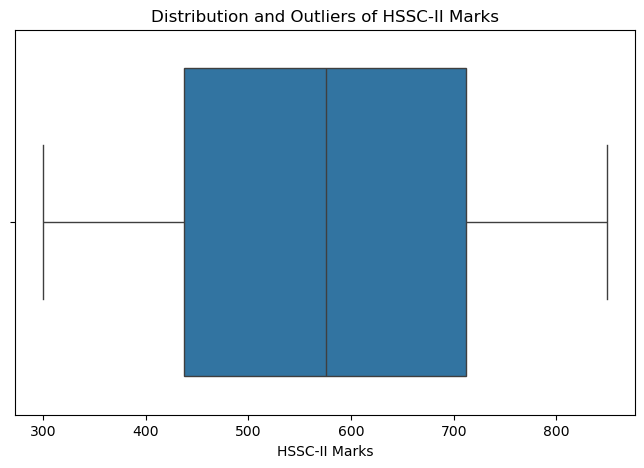

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["HSSC_II_Marks"])

plt.title("Distribution and Outliers of HSSC-II Marks")
plt.xlabel("HSSC-II Marks")
plt.show()

#### Observation

The boxplot shows the central distribution and spread of HSSC-II marks and helps identify unusually low or high observations.

## 3.8 Attendance Rate vs HSSC-II Marks

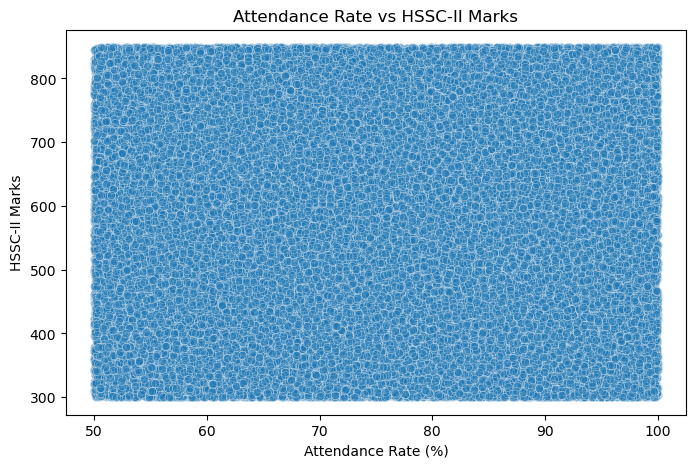

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance_Rate",
    y="HSSC_II_Marks",
    alpha=0.4
)
plt.title("Attendance Rate vs HSSC-II Marks")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("HSSC-II Marks")
plt.show()

#### Observation

The scatter plot is used to examine whether students with different attendance levels show differences in HSSC-II marks. The overall direction and strength of the relationship can be assessed from the distribution of points.

## 3.9 Study Hours vs HSSC-II Marks

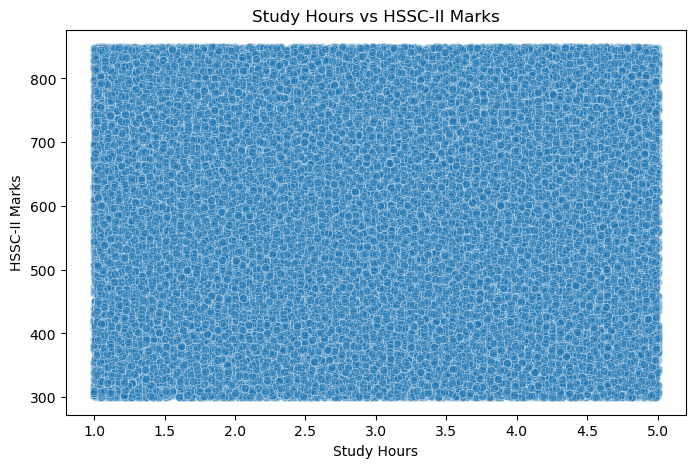

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="HSSC_II_Marks",
    alpha=0.4
)
plt.title("Study Hours vs HSSC-II Marks")
plt.xlabel("Study Hours")
plt.ylabel("HSSC-II Marks")
plt.show()

#### Observation

The scatter plot shows the relationship between study hours and HSSC-II marks.

## 3.10 Correlation Heatmap

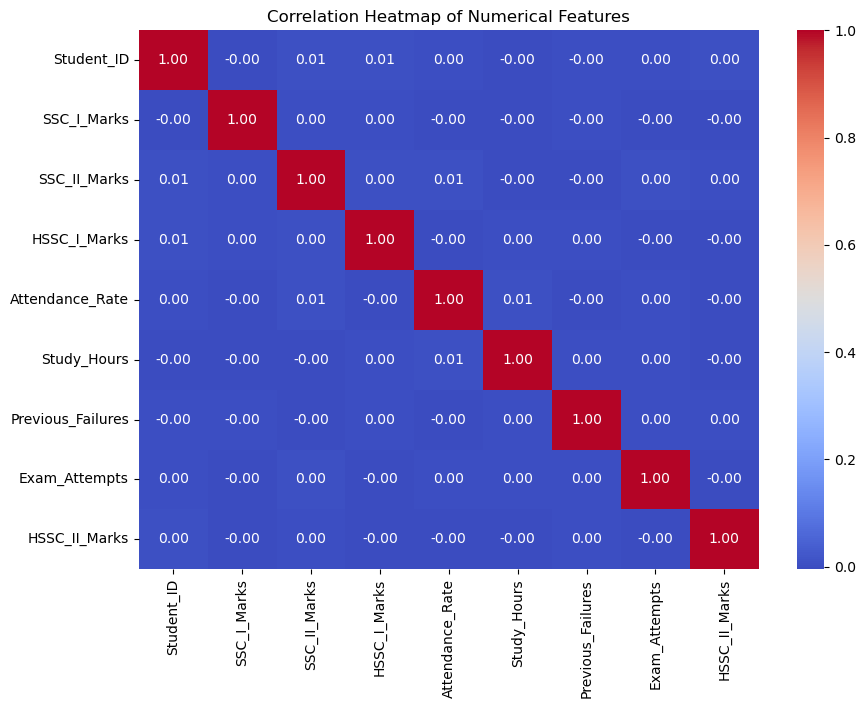

In [17]:
plt.figure(figsize=(10, 7))

numeric_columns = df.select_dtypes(include=np.number).columns
sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

#### Observation

The correlation heatmap shows the strength and direction of relationships among numerical variables. It helps identify features that have stronger or weaker associations with other numerical variables and supports later feature selection decisions.

## 4. Data Understanding – Phase 2 (Problem Finding in Data)

### 4.1 Check Missing Values

In [18]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Student_ID                  0
Region                      0
Gender                      0
Enrollment_Type             0
Subject_Group               0
SSC_I_Marks                 0
SSC_II_Marks                0
HSSC_I_Marks                0
Attendance_Rate             0
Parent_Education_Level      0
Parent_Income               0
Study_Hours                 0
Extra_Tuition               0
School_Type                 0
Previous_Failures           0
Co_Curricular_Activities    0
Exam_Attempts               0
HSSC_II_Marks               0
HSSC_II_Grade               0
dtype: int64

Total missing values: 0


### 4.2 Check Duplicate Records

In [21]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


### 4.3 Check Data Types

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Student_ID                90000 non-null  int64  
 1   Region                    90000 non-null  object 
 2   Gender                    90000 non-null  object 
 3   Enrollment_Type           90000 non-null  object 
 4   Subject_Group             90000 non-null  object 
 5   SSC_I_Marks               90000 non-null  int64  
 6   SSC_II_Marks              90000 non-null  int64  
 7   HSSC_I_Marks              90000 non-null  int64  
 8   Attendance_Rate           90000 non-null  float64
 9   Parent_Education_Level    90000 non-null  object 
 10  Parent_Income             90000 non-null  object 
 11  Study_Hours               90000 non-null  float64
 12  Extra_Tuition             90000 non-null  object 
 13  School_Type               90000 non-null  object 
 14  Previo

### 4.4 Check Categorical Values

In [23]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


Region
['Mohmand' 'Khyber' 'Chitral' 'Charsadda' 'Peshawar']

Gender
['Male' 'Female']

Enrollment_Type
['Regular' 'Private']

Subject_Group
['Science' 'Arts']

Parent_Education_Level
['College' 'Graduate' 'High School']

Parent_Income
['Medium' 'Low' 'High']

Extra_Tuition
['No' 'Yes']

School_Type
['Private' 'Public']

Co_Curricular_Activities
['No' 'Yes']

HSSC_II_Grade
['A-ONE' 'C' 'B' 'Fail' 'A' 'D']


### 4.5 Numerical Outliers Detection

In [26]:
numerical_analysis_columns = [
    "SSC_I_Marks",
    "SSC_II_Marks",
    "HSSC_I_Marks",
    "Attendance_Rate",
    "Study_Hours",
    "Previous_Failures",
    "Exam_Attempts",
    "HSSC_II_Marks"
]

In [27]:
for column in numerical_analysis_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = (
        (df[column] < lower) |
        (df[column] > upper)
    ).sum()
    print(f"{column}: {count} potential outliers")

SSC_I_Marks: 0 potential outliers
SSC_II_Marks: 0 potential outliers
HSSC_I_Marks: 0 potential outliers
Attendance_Rate: 0 potential outliers
Study_Hours: 0 potential outliers
Previous_Failures: 0 potential outliers
Exam_Attempts: 0 potential outliers
HSSC_II_Marks: 0 potential outliers


### 4.6 Valid Range Checks

In [28]:
print("SSC-I invalid values:",
      ((df["SSC_I_Marks"] < 300) | (df["SSC_I_Marks"] > 849)).sum())

print("SSC-II invalid values:",
      ((df["SSC_II_Marks"] < 300) | (df["SSC_II_Marks"] > 849)).sum())

print("HSSC-I invalid values:",
      ((df["HSSC_I_Marks"] < 300) | (df["HSSC_I_Marks"] > 849)).sum())

print("HSSC-II invalid values:",
      ((df["HSSC_II_Marks"] < 300) | (df["HSSC_II_Marks"] > 849)).sum())

print("Attendance invalid values:",
      ((df["Attendance_Rate"] < 0) | (df["Attendance_Rate"] > 100)).sum())

print("Study Hours invalid values:",
      ((df["Study_Hours"] < 0) | (df["Study_Hours"] > 24)).sum())

SSC-I invalid values: 0
SSC-II invalid values: 0
HSSC-I invalid values: 0
HSSC-II invalid values: 0
Attendance invalid values: 0
Study Hours invalid values: 0


### 4.7 Class Distribution

In [29]:
class_counts = df["HSSC_II_Grade"].value_counts()

print(class_counts)
print("\nClass percentages:")
print((class_counts / len(df) * 100).round(2))

HSSC_II_Grade
B        16584
Fail     16462
A        16355
C        16282
D        16172
A-ONE     8145
Name: count, dtype: int64

Class percentages:
HSSC_II_Grade
B        18.43
Fail     18.29
A        18.17
C        18.09
D        17.97
A-ONE     9.05
Name: count, dtype: float64


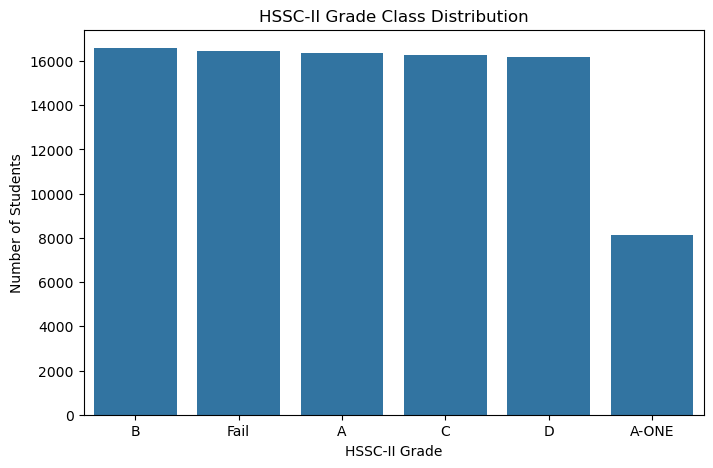

In [30]:
#Visualization
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="HSSC_II_Grade",
    order=class_counts.index
)
plt.title("HSSC-II Grade Class Distribution")
plt.xlabel("HSSC-II Grade")
plt.ylabel("Number of Students")
plt.show()

#### Observation

The target variable contains six classes. The A-ONE class has fewer observations than the other major classes, while the remaining classes have relatively similar representation.

Class imbalance will therefore be evaluated before deciding whether oversampling is necessary.

## 5. Data Preprocessing

### 5.1 Remove Duplicates

In [31]:
df = df.drop_duplicates().copy()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (90000, 19)


### 5.2 Separate Target and Remove Irrelevant/Leakage Columns

In [32]:
target = "HSSC_II_Grade"
X = df.drop(
    columns=[
        "Student_ID",
        "HSSC_II_Marks",
        target
    ]
)
y = df[target]
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (90000, 16)
Target shape: (90000,)


### 5.3 Fix Categorical Inconsistencies

In [33]:
categorical_columns = X.select_dtypes(include="object").columns

for column in categorical_columns:
    X[column] = X[column].astype(str).str.strip()

print("Categorical values after cleaning:")

for column in categorical_columns:
    print(f"\n{column}:")
    print(X[column].unique())

Categorical values after cleaning:

Region:
['Mohmand' 'Khyber' 'Chitral' 'Charsadda' 'Peshawar']

Gender:
['Male' 'Female']

Enrollment_Type:
['Regular' 'Private']

Subject_Group:
['Science' 'Arts']

Parent_Education_Level:
['College' 'Graduate' 'High School']

Parent_Income:
['Medium' 'Low' 'High']

Extra_Tuition:
['No' 'Yes']

School_Type:
['Private' 'Public']

Co_Curricular_Activities:
['No' 'Yes']


### 5.4 Train-Test Split

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (72000, 16)
Testing data: (18000, 16)


### 5.5 Handle Outliers

In [35]:
valid_ranges = {
    "SSC_I_Marks": (300, 849),
    "SSC_II_Marks": (300, 849),
    "HSSC_I_Marks": (300, 849),
    "Attendance_Rate": (0, 100),
    "Study_Hours": (0, 24),
    "Previous_Failures": (0, 2),
    "Exam_Attempts": (1, 2)
}
for column, (lower, upper) in valid_ranges.items():

    invalid_train = (
        (X_train[column] < lower) |
        (X_train[column] > upper)
    ).sum()
    invalid_test = (
        (X_test[column] < lower) |
        (X_test[column] > upper)
    ).sum()
    print(
        f"{column}: "
        f"Training invalid = {invalid_train}, "
        f"Testing invalid = {invalid_test}"
    )

SSC_I_Marks: Training invalid = 0, Testing invalid = 0
SSC_II_Marks: Training invalid = 0, Testing invalid = 0
HSSC_I_Marks: Training invalid = 0, Testing invalid = 0
Attendance_Rate: Training invalid = 0, Testing invalid = 0
Study_Hours: Training invalid = 0, Testing invalid = 0
Previous_Failures: Training invalid = 0, Testing invalid = 0
Exam_Attempts: Training invalid = 0, Testing invalid = 0


### 5.6 Encode Categorical Features

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()
numerical_features = X_train.select_dtypes(
    exclude="object"
).columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=feature_names,
    index=X_train.index
)
X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=feature_names,
    index=X_test.index
)
print("Training data after encoding:", X_train_encoded.shape)
print("Testing data after encoding:", X_test_encoded.shape)

Training data after encoding: (72000, 30)
Testing data after encoding: (18000, 30)


## 6. Feature Selection

### 6.1 Correlation Analysis

In [37]:
target_encoded = y_train.astype("category").cat.codes

correlation_scores = (
    X_train_encoded
    .corrwith(target_encoded)
    .abs()
    .sort_values(ascending=False)
)
print("Top 10 features based on correlation:")
display(correlation_scores.head(10))

Top 10 features based on correlation:


categorical__Region_Khyber                         0.009872
categorical__Parent_Income_Medium                  0.009772
categorical__Region_Peshawar                       0.009303
categorical__Parent_Education_Level_High School    0.009287
categorical__Parent_Income_High                    0.007485
categorical__Parent_Education_Level_Graduate       0.007096
numerical__HSSC_I_Marks                            0.005890
categorical__Enrollment_Type_Regular               0.004681
categorical__Enrollment_Type_Private               0.004681
categorical__Extra_Tuition_No                      0.004674
dtype: float64

### 6.2 Random Forest Feature Importance

In [38]:
from sklearn.ensemble import RandomForestClassifier
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_selector.fit(
    X_train_encoded,
    y_train
)
rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_encoded.columns
).sort_values(ascending=False)
print("Top 10 Random Forest features:")
display(rf_importance.head(10))

Top 10 Random Forest features:


numerical__Attendance_Rate          0.123685
numerical__SSC_II_Marks             0.122030
numerical__HSSC_I_Marks             0.121723
numerical__SSC_I_Marks              0.121670
numerical__Study_Hours              0.121225
numerical__Previous_Failures        0.039410
numerical__Exam_Attempts            0.024373
categorical__School_Type_Private    0.016319
categorical__School_Type_Public     0.016217
categorical__Extra_Tuition_Yes      0.015280
dtype: float64

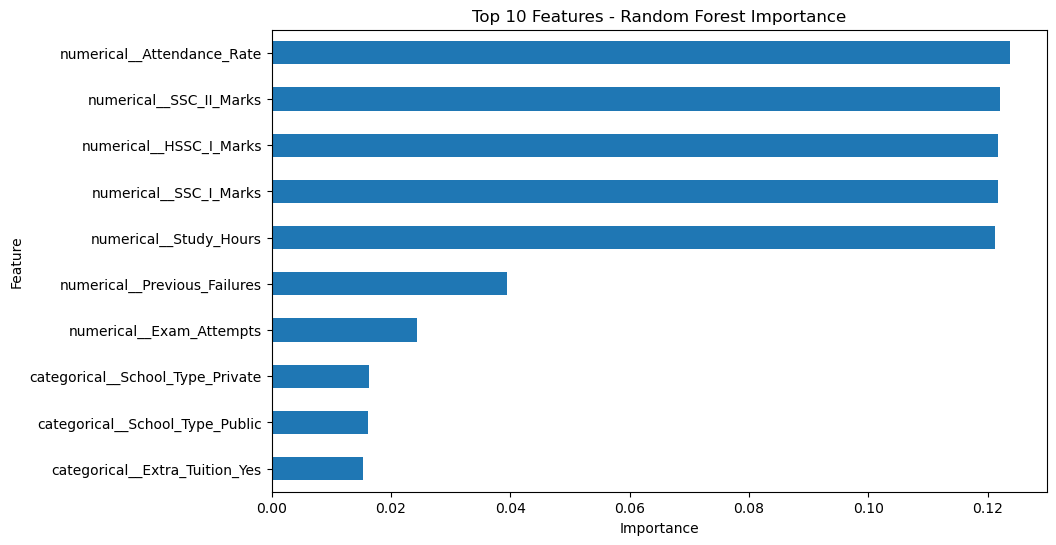

In [39]:
#Visualization
plt.figure(figsize=(10, 6))
rf_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Features - Random Forest Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### 6.3 Chi-Square Test

In [40]:
from sklearn.feature_selection import chi2
chi_scores_array, chi_pvalues = chi2(
    X_train_encoded,
    y_train
)
chi_scores = pd.Series(
    chi_scores_array,
    index=X_train_encoded.columns
).sort_values(ascending=False)
print("Top 10 Chi-Square features:")
display(chi_scores.head(10))

Top 10 Chi-Square features:


numerical__HSSC_I_Marks                            553.947918
numerical__SSC_I_Marks                             150.162290
numerical__SSC_II_Marks                             46.100472
numerical__Attendance_Rate                          10.958163
categorical__Parent_Income_Medium                    8.939311
categorical__Region_Khyber                           8.708752
categorical__Parent_Education_Level_High School      7.113357
categorical__Region_Peshawar                         6.688265
categorical__Gender_Female                           5.204928
categorical__Gender_Male                             5.179256
dtype: float64

### 6.4 Mutual Information

In [41]:
from sklearn.feature_selection import mutual_info_classif
mi_scores_array = mutual_info_classif(
    X_train_encoded,
    y_train,
    random_state=42
)
mi_scores = pd.Series(
    mi_scores_array,
    index=X_train_encoded.columns
).sort_values(ascending=False)
print("Top 10 Mutual Information features:")
display(mi_scores.head(10))

Top 10 Mutual Information features:


categorical__Gender_Female                         0.008170
numerical__Previous_Failures                       0.005793
categorical__Enrollment_Type_Private               0.005336
categorical__Parent_Education_Level_Graduate       0.005196
categorical__Parent_Education_Level_High School    0.004845
categorical__Region_Charsadda                      0.003661
numerical__SSC_I_Marks                             0.003527
categorical__School_Type_Public                    0.003408
categorical__Subject_Group_Arts                    0.002742
categorical__Gender_Male                           0.002720
dtype: float64

### 6.5 Feature Selection Voting

In [42]:
top_n = 10
top_rf = set(rf_importance.head(top_n).index)
top_chi = set(chi_scores.head(top_n).index)
top_mi = set(mi_scores.head(top_n).index)
votes = pd.Series(
    0,
    index=X_train_encoded.columns
)
for feature in top_rf:
    votes[feature] += 1

for feature in top_chi:
    votes[feature] += 1

for feature in top_mi:
    votes[feature] += 1
votes = votes.sort_values(ascending=False)

display(votes.head(15))

numerical__SSC_I_Marks                             3
numerical__Previous_Failures                       2
numerical__Attendance_Rate                         2
categorical__Gender_Female                         2
categorical__Gender_Male                           2
numerical__HSSC_I_Marks                            2
numerical__SSC_II_Marks                            2
categorical__School_Type_Public                    2
categorical__Parent_Education_Level_High School    2
categorical__Region_Charsadda                      1
categorical__Parent_Income_Medium                  1
numerical__Study_Hours                             1
categorical__School_Type_Private                   1
categorical__Extra_Tuition_Yes                     1
numerical__Exam_Attempts                           1
dtype: int64

### 6.6 Select Final Features

In [43]:
selected_features = votes[
    votes >= 2
].index.tolist()

print("Number of selected features:", len(selected_features))

print("\nSelected Features:")
for feature in selected_features:
    print("-", feature)

Number of selected features: 9

Selected Features:
- numerical__SSC_I_Marks
- numerical__Previous_Failures
- numerical__Attendance_Rate
- categorical__Gender_Female
- categorical__Gender_Male
- numerical__HSSC_I_Marks
- numerical__SSC_II_Marks
- categorical__School_Type_Public
- categorical__Parent_Education_Level_High School


In [44]:
X_train_selected = X_train_encoded[selected_features].copy()
X_test_selected = X_test_encoded[selected_features].copy()

print("Selected training data:", X_train_selected.shape)
print("Selected testing data:", X_test_selected.shape)

Selected training data: (72000, 9)
Selected testing data: (18000, 9)


#### Feature Selection Decision

Three feature selection techniques were applied:

1. Correlation Analysis
2. Random Forest Feature Importance
3. Mutual Information

A voting strategy was used to combine the results. A feature was retained when at least two of the three techniques identified it among their top-ranked features.

Feature selection was performed using the training data only to avoid data leakage.

## 7. Feature Engineering

### 7.1 Create Previous Academic Performance

In [45]:
def create_engineered_features(data):
    data = data.copy()
    data["Previous_Academic_Performance"] = (
        data["SSC_I_Marks"] +
        data["SSC_II_Marks"] +
        data["HSSC_I_Marks"]
    ) / 3
    data["Study_Attendance_Index"] = (
        data["Study_Hours"] *
        data["Attendance_Rate"]
    ) / 100
    return data

In [46]:
X_train_engineered = X_train.loc[:, [
    col for col in X_train.columns
]].copy()

X_test_engineered = X_test.loc[:, [
    col for col in X_test.columns
]].copy()

X_train_engineered = create_engineered_features(X_train_engineered)
X_test_engineered = create_engineered_features(X_test_engineered)
print(
    X_train_engineered[
        [
            "Previous_Academic_Performance",
            "Study_Attendance_Index"
        ]
    ].head()
)

       Previous_Academic_Performance  Study_Attendance_Index
75969                     489.000000                3.903536
54002                     722.000000                4.065150
13477                     527.333333                2.658309
57990                     520.666667                1.752480
79475                     449.333333                2.017356


## 8. Handling Class Imbalance

### 8.1 Check Class Distribution

In [47]:
class_distribution = y_train.value_counts()
print(class_distribution)
print("\nClass percentages:")
print(
    (class_distribution / len(y_train) * 100)
    .round(2)
)

HSSC_II_Grade
B        13267
Fail     13169
A        13084
C        13026
D        12938
A-ONE     6516
Name: count, dtype: int64

Class percentages:
HSSC_II_Grade
B        18.43
Fail     18.29
A        18.17
C        18.09
D        17.97
A-ONE     9.05
Name: count, dtype: float64


#### Observation

The target classes are not perfectly balanced. The A-ONE class has fewer observations than the other classes, while the remaining classes have relatively similar frequencies.

Because the minority class is underrepresented, SMOTE will be applied to the training data only. The original test distribution will remain unchanged for unbiased evaluation.

## 9. Model Building
### 9.1 Feature Scaling

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

### 9.2 Apply SMOTE

In [49]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)
print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
HSSC_II_Grade
B        13267
Fail     13169
A        13084
C        13026
D        12938
A-ONE     6516
Name: count, dtype: int64

After SMOTE:
HSSC_II_Grade
Fail     13267
B        13267
A        13267
C        13267
D        13267
A-ONE    13267
Name: count, dtype: int64


### 9.3 Logistic Regression

In [50]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logistic_model.fit(
    X_train_balanced,
    y_train_balanced
)
logistic_predictions = logistic_model.predict(
    X_test_scaled
)

### 9.4 Decision Tree

In [51]:
from sklearn.tree import DecisionTreeClassifier
decision_model = DecisionTreeClassifier(
    random_state=42
)
decision_model.fit(
    X_train_balanced,
    y_train_balanced
)
decision_predictions = decision_model.predict(
    X_test_scaled
)

### 9.5 Random Forest

In [52]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
random_forest_model.fit(
    X_train_balanced,
    y_train_balanced
)
random_forest_predictions = random_forest_model.predict(
    X_test_scaled
)

## 10. Model Evaluation
### 10.1 Evaluation Metrics

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

### 10.2 Logistic Regression Evaluation

In [56]:
print("Logistic Regression")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

Logistic Regression
              precision    recall  f1-score   support

           A       0.19      0.25      0.21      3271
       A-ONE       0.09      0.19      0.12      1629
           B       0.18      0.21      0.19      3317
           C       0.17      0.14      0.15      3256
           D       0.17      0.15      0.16      3234
        Fail       0.18      0.04      0.07      3293

    accuracy                           0.16     18000
   macro avg       0.16      0.16      0.15     18000
weighted avg       0.17      0.16      0.16     18000



### 10.3 Decision Tree Evaluation

In [59]:
print("Decision Tree")

print(
    classification_report(
        y_test,
        decision_predictions,
        zero_division=0
    )
)

Decision Tree
              precision    recall  f1-score   support

           A       0.18      0.17      0.18      3271
       A-ONE       0.10      0.15      0.12      1629
           B       0.18      0.17      0.17      3317
           C       0.17      0.17      0.17      3256
           D       0.18      0.18      0.18      3234
        Fail       0.20      0.18      0.19      3293

    accuracy                           0.17     18000
   macro avg       0.17      0.17      0.17     18000
weighted avg       0.18      0.17      0.17     18000



### 10.4 Random Forest Evaluation

In [60]:
print("Random Forest")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        zero_division=0
    )
)

Random Forest
              precision    recall  f1-score   support

           A       0.18      0.18      0.18      3271
       A-ONE       0.09      0.13      0.11      1629
           B       0.19      0.19      0.19      3317
           C       0.18      0.17      0.18      3256
           D       0.19      0.19      0.19      3234
        Fail       0.18      0.16      0.17      3293

    accuracy                           0.17     18000
   macro avg       0.17      0.17      0.17     18000
weighted avg       0.18      0.17      0.18     18000



### 10.5 Model Performance

In [61]:
models = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_predictions,
    "Random Forest": random_forest_predictions
}
results = []
for model_name, predictions in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })
comparison = pd.DataFrame(results)

comparison.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.174444,0.177426,0.174444,0.175617
1,Decision Tree,0.171056,0.175341,0.171056,0.172569
0,Logistic Regression,0.162000,0.170654,0.162000,0.155326


### 10.6 Model Performance Graph

<Figure size 1000x600 with 0 Axes>

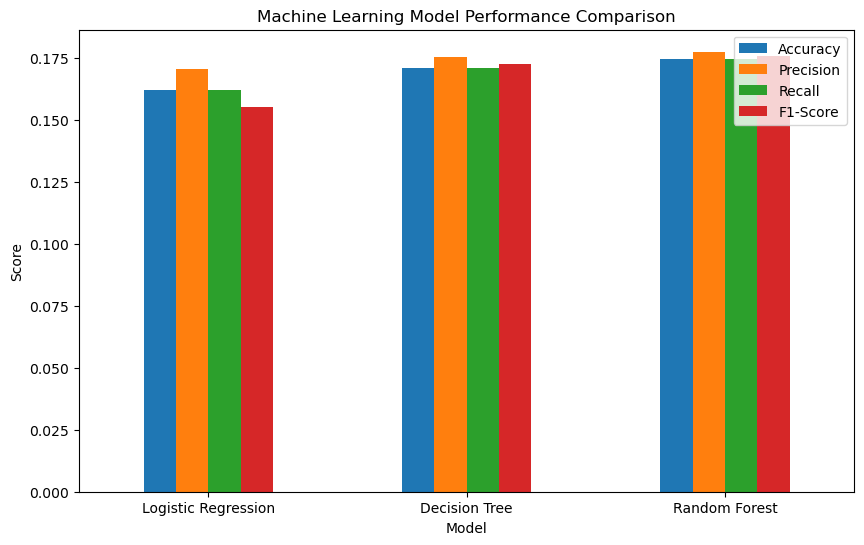

In [62]:
comparison_plot = comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]
plt.figure(figsize=(10, 6))

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### 10.7 Select Best Model

In [63]:
best_model_row = comparison.loc[
    comparison["F1-Score"].idxmax()
]
best_model_name = best_model_row["Model"]
print("Best Performing Model:", best_model_name)
print("\nPerformance:")
display(best_model_row.to_frame().T)

Best Performing Model: Random Forest

Performance:


,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.174444,0.177426,0.174444,0.175617


### 10.8 Confusion Matrix

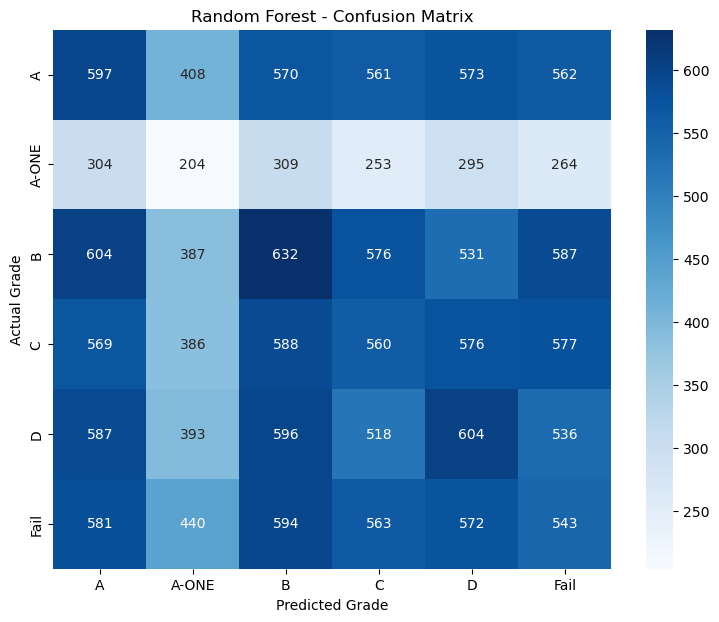

In [64]:
prediction_dictionary = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_predictions,
    "Random Forest": random_forest_predictions
}
best_predictions = prediction_dictionary[best_model_name]

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=sorted(y_test.unique())
)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)
plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted Grade")
plt.ylabel("Actual Grade")
plt.show()

# 11. Final Conclusion

### 11.1 Project Summary

This project developed a Machine Learning-based Student Academic Success Prediction System using the BISEP Student Performance Prediction Dataset.

The dataset contains 90,000 student records and 19 columns covering academic, demographic, socioeconomic, and behavioral information.

The complete Machine Learning lifecycle was followed, including:

- Problem Understanding
- Data Collection
- Exploratory Data Analysis
- Data Quality Analysis
- Data Preprocessing
- Feature Selection
- Feature Engineering
- Class Imbalance Handling
- Model Building
- Model Evaluation

Three classification models were developed and compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models were evaluated using Accuracy, Precision, Recall, and F1-Score.

### 11.2 Best-Performing Model

In [65]:
print("Best Performing Model:", best_model_name)
display(
    comparison[
        comparison["Model"] == best_model_name
    ]
)

Best Performing Model: Random Forest


,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.174444,0.177426,0.174444,0.175617


### Best-Performing Model

The best-performing model was selected based on the highest weighted F1-Score.

The final model selection is based on performance on the unseen test dataset rather than the training dataset.

### 11.3 Limitations

- Model performance depends on the quality and representativeness of the available dataset.
- The dataset may not capture every factor that influences student academic performance.
- Factors such as teaching quality, learning environment, personal circumstances, and student well-being are not fully represented.
- The prediction task contains six academic grade classes, which makes classification more challenging.
- The model should be considered a decision-support tool and not a replacement for teachers' or educational institutions' judgment.

### 11.4 Future Improvements

Future improvements may include:

- Hyperparameter tuning for the Machine Learning models.
- Cross-validation for more robust performance estimation.
- Testing additional algorithms such as XGBoost and Support Vector Machine.
- Collecting additional student-related features.
- Applying explainable AI techniques to understand individual predictions.
- Developing a web-based interface for real-time student grade prediction.
- Deploying the trained model as an educational decision-support application.

# 12. Frontend / Deployment

## 12.1 Frontend Technology

A simple interactive web application was developed using Streamlit.

Streamlit was selected because it provides a simple and effective way to integrate a trained Machine Learning model with an interactive user interface.

The application allows users to enter student information and obtain a predicted HSSC-II academic grade.

In [68]:
import joblib

## 12.2 Save Final Model

The best-performing Machine Learning model was saved using Joblib so that it can be reused in the Streamlit application without retraining the model.

In [80]:
best_model = models[best_model_name]

In [81]:
# Select the trained best-performing model

if best_model_name == "Logistic Regression":
    best_model = logistic_model

elif best_model_name == "Decision Tree":
    best_model = decision_model

elif best_model_name == "Random Forest":
    best_model = random_forest_model

print("Best Model:", best_model_name)
print("Model Type:", type(best_model).__name__)

Best Model: Random Forest
Model Type: RandomForestClassifier


In [82]:
# Save the trained best-performing model
joblib.dump(best_model, "student_grade_model.pkl")
print("Final trained model saved successfully.")

Final trained model saved successfully.


## 12.3 Save Preprocessing Objects

The preprocessing components used during model development are saved so that new data entered through the frontend is transformed consistently with the training data.

In [74]:
# Save preprocessing components
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selected_features, "selected_features.pkl")
print("Preprocessing objects saved successfully.")

Preprocessing objects saved successfully.


## 12.4 Verify Saved Files

The saved Machine Learning model and preprocessing components are verified before integrating them into the frontend application.

In [75]:
import os
required_files = [
    "student_grade_model.pkl",
    "preprocessor.pkl",
    "scaler.pkl",
    "selected_features.pkl"
]
for file in required_files:
    if os.path.exists(file):
        print(f"✓ {file} found")
    else:
        print(f"✗ {file} not found")

✓ student_grade_model.pkl found
✓ preprocessor.pkl found
✓ scaler.pkl found
✓ selected_features.pkl found


## 12.5 Test Saved Model

The saved model and preprocessing components are reloaded to verify that the complete prediction pipeline works correctly after serialization.

This test ensures that the model can be used independently from the training process, which is necessary for frontend deployment.

In [83]:
# Reload saved model and preprocessing components
loaded_model = joblib.load("student_grade_model.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_selected_features = joblib.load("selected_features.pkl")
print("Saved model and preprocessing components loaded successfully.")

Saved model and preprocessing components loaded successfully.


In [2]:
# Verify loaded objects
import joblib
loaded_model = joblib.load("student_grade_model.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_selected_features = joblib.load("selected_features.pkl")
print("Model:", type(loaded_model).__name__)
print("Preprocessor:", type(loaded_preprocessor).__name__)
print("Scaler:", type(loaded_scaler).__name__)
print("Number of selected features:", len(loaded_selected_features))

Model: RandomForestClassifier
Preprocessor: ColumnTransformer
Scaler: StandardScaler
Number of selected features: 12


## 12.6 Create Streamlit Application

An interactive frontend was developed using Streamlit to allow users to enter student information and obtain a predicted academic grade from the trained Random Forest model.

The application uses the saved Machine Learning model and preprocessing components so that new inputs are processed consistently with the training pipeline.